## Online Retail Analysis

### Load Dataset

In [34]:
## Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
## Load the dataset
df = pd.read_excel("./Dataset/Online Retail.xlsx")

In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [37]:
## Some basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [38]:
## Basic descriptive statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Data Preprocessing

In [39]:
## Check for duplicate values
df.duplicated().sum()

np.int64(5268)

In [40]:
## Drop duplicate values
df.drop_duplicates(inplace=True)

In [41]:
## Check total no. of null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [42]:
## Percentage of null values contains each column
(df.isnull().sum()/df.shape[0])*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.270945
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     25.163377
Country         0.000000
dtype: float64

In [43]:
## Remove null values
df.dropna(subset=['Description', 'CustomerID'], inplace=True)

In [44]:
## After removing all null values check percentage of null values in each column
(df.isnull().sum()/df.shape[0])*100

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [45]:
## Remove negative quantity
df = df[df['Quantity'] > 0]

## Remove zero or negative price
df = df[df['UnitPrice'] > 0]


In [46]:
## Shape of the dataset after cleaning
df.shape

(392692, 8)

In [47]:
## Check total no. of unique customer
df['CustomerID'].nunique()

4338

#### Comments:
In our dataset we have **4338** unique customers.

In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [49]:
(df['InvoiceDate'].max() - df['InvoiceDate'].min())

Timedelta('373 days 04:24:00')

### Feature Creation

In [50]:
## Create Total Price Column
df['Total_Price'] = df['Quantity']*df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [51]:
## Last date of purchasing
reference_date = df['InvoiceDate'].max()
reference_date

Timestamp('2011-12-09 12:50:00')

In [52]:
rfm_df = df.groupby(['CustomerID']).aggregate({
    'InvoiceDate' : lambda x:(reference_date-x.max()).days,
    'InvoiceNo' :'count',
    'Total_Price' : 'sum'
})

rfm_df


,InvoiceDate,InvoiceNo,Total_Price
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [53]:
# Rename columns
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
rfm_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


### EDA

In [54]:
for index, i in enumerate(rfm_df.columns):
    print(index, i)

0 Recency
1 Frequency
2 Monetary


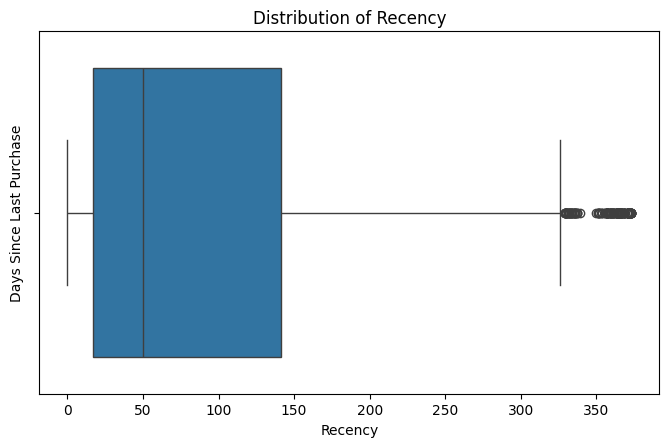

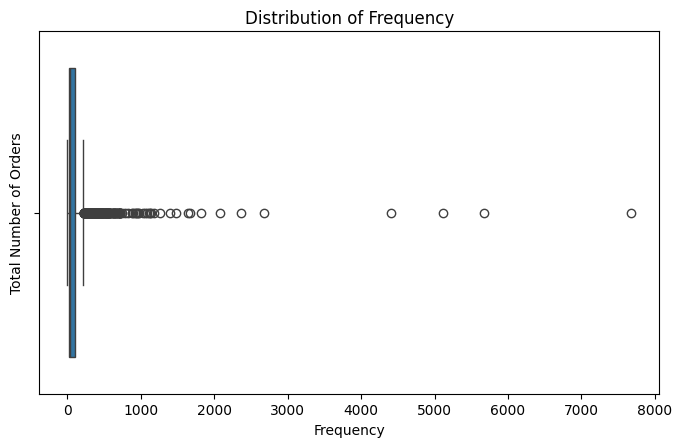

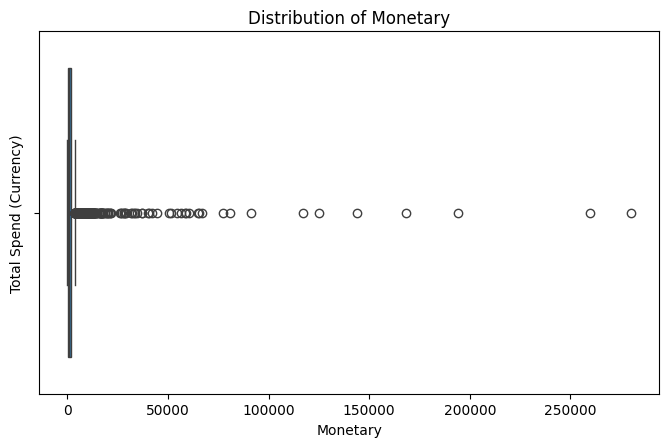

In [55]:
y_label = ["Days Since Last Purchase", "Total Number of Orders", "Total Spend (Currency)"]

for index, i in enumerate(rfm_df.columns):
    plt.figure(figsize=(8,16))
    plt.subplot(3, 1, index+1)

    sns.boxplot(data=rfm_df, x=i)
    plt.xlabel(i)
    plt.ylabel(y_label[index])
    plt.title(f"Distribution of {i}")
    

#### Comments:
From the above analysis we can see that RFM values are highly skewed, so to handle skewness we apply log transformer.

### Feature Transformation

In [56]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer

## Create instantiate
scaler = StandardScaler()
transformer = FunctionTransformer(np.log1p)

In [57]:
rfm_df_transformed = transformer.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])
rfm_df_transformed 

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.786897,0.693147,11.253955
12347.0,0.693147,5.209486,8.368925
12348.0,4.317488,3.465736,7.494564
12349.0,2.944439,4.304065,7.472245
12350.0,5.736572,2.890372,5.815324
...,...,...,...
18280.0,5.627621,2.397895,5.201806
18281.0,5.198497,2.079442,4.404522
18282.0,2.079442,2.564949,5.187665


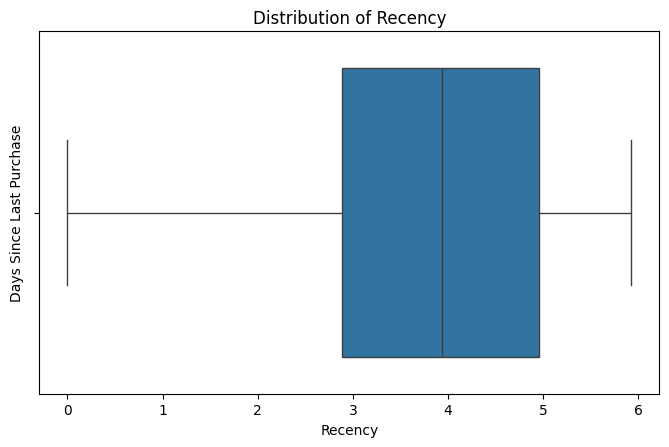

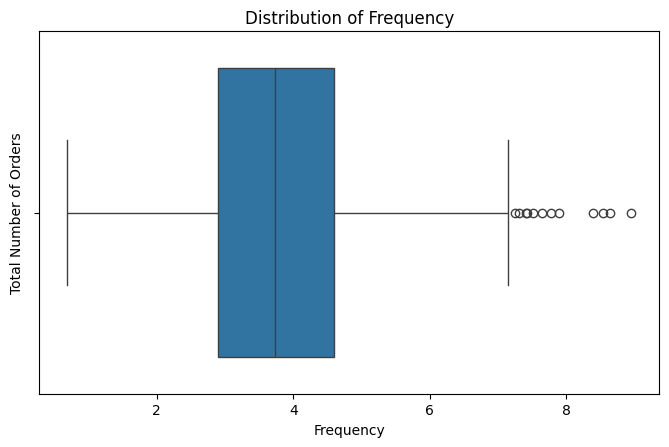

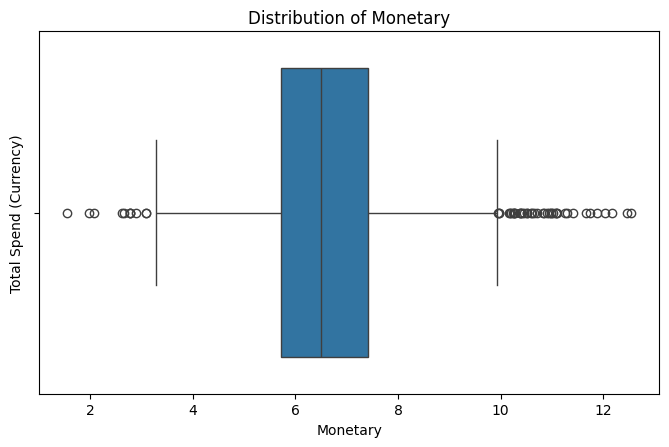

In [58]:
y_label = ["Days Since Last Purchase", "Total Number of Orders", "Total Spend (Currency)"]

## After applying log transformation we get distribution of Recency, Frequency, Monetory
for index, i in enumerate(rfm_df_transformed.columns):
    plt.figure(figsize=(8,16))
    plt.subplot(3, 1, index+1)

    sns.boxplot(data=rfm_df_transformed, x=i)
    plt.xlabel(i)
    plt.ylabel(y_label[index])
    plt.title(f"Distribution of {i}")

In [59]:
## Fixing Recency Direction
rfm_df_transformed['Recency'] = -rfm_df_transformed['Recency']

#### Comments:
✔️ What it does:

It Converts:
```
High Recency (bad) → low value
Low Recency (good) → high value
```

In [60]:
## Scaling
rfm_df_scaled = scaler.fit_transform(rfm_df_transformed[['Recency', 'Frequency', 'Monetary']])
rfm_df_scaled

array([[-1.40989446, -2.43820181,  3.7077163 ],
       [ 2.14649825,  1.18898578,  1.41490344],
       [-0.38397128, -0.21146474,  0.72002428],
       ...,
       [ 1.17860486, -0.9349095 , -1.11333158],
       [ 1.66255156,  2.29130702,  0.82281217],
       [ 0.00442205,  0.42858139,  0.73752572]], shape=(4338, 3))

## K-Means Clustering

### Elbow Method

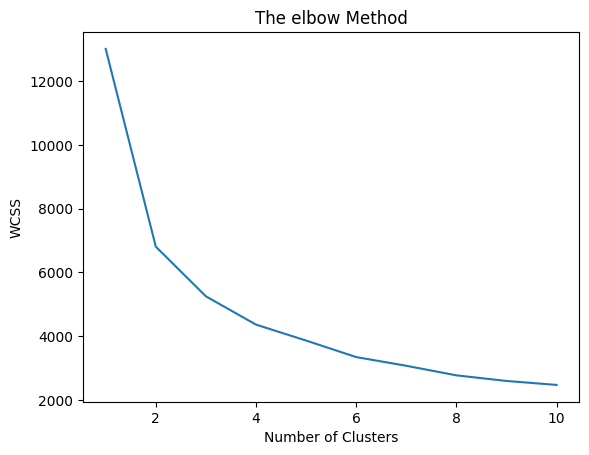

In [61]:
from sklearn.cluster import KMeans
## Within cluster sum of square
## To store Variance with in clusters
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_df_scaled) ## Fit input data

    ## Model output which gives within sum of square
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1,11), y=wcss)
plt.title('The elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS');


In [62]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 7)  ## Silhouette not valid for K=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_df_scaled)
    
    score = silhouette_score(rfm_df_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3994
K=3, Silhouette Score=0.3068
K=4, Silhouette Score=0.3076
K=5, Silhouette Score=0.2771
K=6, Silhouette Score=0.2732


### K-Means Clustering with k=3

In [63]:
## Model creation
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

labels = kmeans.fit_predict(rfm_df_scaled)

labels

array([1, 2, 1, ..., 0, 2, 1], shape=(4338,), dtype=int32)

In [64]:
rfm_df['Cluster'] = labels
rfm_df

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,1
12347.0,1,182,4310.00,2
12348.0,74,31,1797.24,1
12349.0,18,73,1757.55,1
12350.0,309,17,334.40,0
...,...,...,...,...
18280.0,277,10,180.60,0
18281.0,180,7,80.82,0
18282.0,7,12,178.05,0


In [65]:
rfm_df.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,167.674745,15.229592,296.558840
1,66.853021,66.111051,1197.346697
2,12.177921,265.129689,6669.537781


In [66]:
cluster_map = {
    0: "Churn Risk Customers",
    1: "Regular Customers",
    2: "VIP Customers"
}

rfm_df['Cluster_Label'] = rfm_df['Cluster'].map(cluster_map)
rfm_df

,Recency,Frequency,Monetary,Cluster,Cluster_Label
CustomerID,,,,,
12346.0,325,1,77183.60,1,Regular Customers
12347.0,1,182,4310.00,2,VIP Customers
12348.0,74,31,1797.24,1,Regular Customers
12349.0,18,73,1757.55,1,Regular Customers
12350.0,309,17,334.40,0,Churn Risk Customers
...,...,...,...,...,...
18280.0,277,10,180.60,0,Churn Risk Customers
18281.0,180,7,80.82,0,Churn Risk Customers
18282.0,7,12,178.05,0,Churn Risk Customers


#### Comments:

From the above analysis we can say that **Cluster 2** represents **high-value customers with low recency, high frequency, and high monetary value**, while **Cluster 0** represents **churn-risk customers with low engagement**. **Cluster 1** consists of **regular customers with moderate activity**.